# IPS Transition — shareout charts

Matplotlib figures for Round 1 discovery shareouts.

Prereq: `analysis.ipynb` outputs in `output/processed/`.
Exports PNG + PDF → `output/diagrams/`.


In [28]:
%pip install -q matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

PROCESSED = Path("output/processed")
OUT_DIR = Path("output/diagrams")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NAVY = "#1B3A4B"
TEAL = "#2A9D8F"
CORAL = "#E76F51"
SLATE = "#4A5568"
LIGHT = "#F7F4EF"
GOLD = "#C9A227"
MUTED = "#94A3B8"

CATEGORY_ORDER = [
    "Workflow & Business Processes",
    "Case Management",
    "Data Management & Visibility",
    "Records & Document Management",
    "System Integration",
    "Reporting & Decision Support",
    "Communication & Collaboration",
    "Scheduling & Resource Management",
    "User Experience & Performance",
    "Training & Documentation",
]

SHORT_CAT = {
    "Workflow & Business Processes": "Workflow & Process",
    "Case Management": "Case Management",
    "Data Management & Visibility": "Data & Visibility",
    "Records & Document Management": "Records & Documents",
    "System Integration": "System Integration",
    "Reporting & Decision Support": "Reporting & Decisions",
    "Communication & Collaboration": "Communication",
    "Scheduling & Resource Management": "Scheduling & Resources",
    "User Experience & Performance": "UX & Performance",
    "Training & Documentation": "Training & Docs",
}

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": MUTED,
        "axes.labelcolor": NAVY,
        "axes.titlecolor": NAVY,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save(fig, name: str):
    png = OUT_DIR / f"{name}.png"
    pdf = OUT_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=180, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print(f"Saved {png}")


challenges = pd.read_csv(PROCESSED / "categorized_challenges.csv")
expectations = pd.read_csv(PROCESSED / "categorized_expectations.csv")
ch_scored = pd.read_csv(PROCESSED / "challenges_scored.csv")
ex_scored = pd.read_csv(PROCESSED / "expectations_scored.csv")

print(
    f"{len(challenges)} challenges · {len(expectations)} expectations · "
    f"{challenges['focus_group'].nunique()} focus groups"
)


992 challenges · 575 expectations · 20 focus groups


## 1. Discovery metrics (shareout)

Edit `STAKEHOLDERS_INTERVIEWED` below if you have a headcount. Pain points and expectations pull from the processed CSVs.


,Metric,Value
0,Discovery sessions,18
1,Departments represented,10+
2,Focus groups,18
3,Stakeholders interviewed,XX
4,Pain points captured,1182
5,Future expectations,385
6,Challenge categories,10


Saved output/diagrams/00_discovery_metrics.png


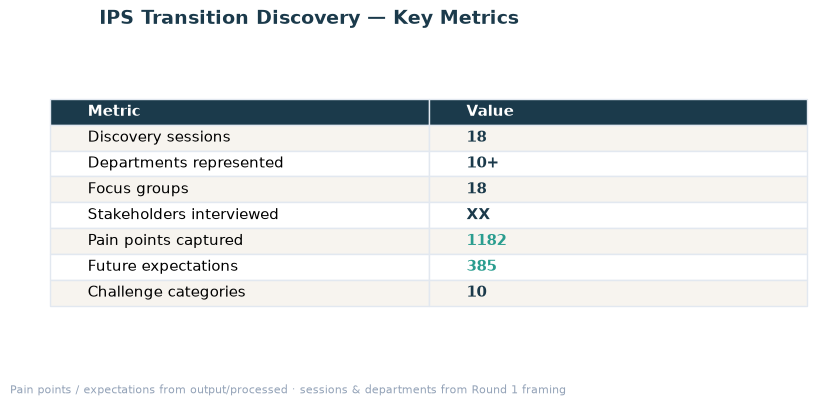

In [30]:
# Fixed shareout facts (from project framing)
DISCOVERY_SESSIONS = 18
DEPARTMENTS_REPRESENTED = "10+"
FOCUS_GROUPS = 18
STAKEHOLDERS_INTERVIEWED = "XX"  # set when known, e.g. 85

# From dataset
pain_points_captured = len(pd.read_csv(PROCESSED / "challenges.csv"))
future_expectations = len(pd.read_csv(PROCESSED / "expectations.csv"))
challenge_categories = int(challenges["Category"].nunique())

metrics = pd.DataFrame(
    [
        ("Discovery sessions", DISCOVERY_SESSIONS),
        ("Departments represented", DEPARTMENTS_REPRESENTED),
        ("Focus groups", FOCUS_GROUPS),
        ("Stakeholders interviewed", STAKEHOLDERS_INTERVIEWED),
        ("Pain points captured", pain_points_captured),
        ("Future expectations", future_expectations),
        ("Challenge categories", challenge_categories),
    ],
    columns=["Metric", "Value"],
)
display(metrics)

# Slide-ready table figure
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axis("off")
ax.set_title("IPS Transition Discovery — Key Metrics", loc="left", fontsize=14, color=NAVY, pad=12)

table = ax.table(
    cellText=metrics.values.tolist(),
    colLabels=metrics.columns.tolist(),
    loc="center",
    cellLoc="left",
    colLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.15, 1.55)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("#E2E8F0")
    if r == 0:
        cell.set_facecolor(NAVY)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(LIGHT if r % 2 else "white")
        if c == 1:
            cell.set_text_props(fontweight="bold", color=TEAL if r in (5, 6) else NAVY)

fig.text(
    0.02,
    0.04,
    "Pain points / expectations from output/processed · sessions & departments from Round 1 framing",
    fontsize=8,
    color=MUTED,
)
save(fig, "00_discovery_metrics")
plt.show()


## 2. Executive snapshot


Saved output/diagrams/01_executive_snapshot.png


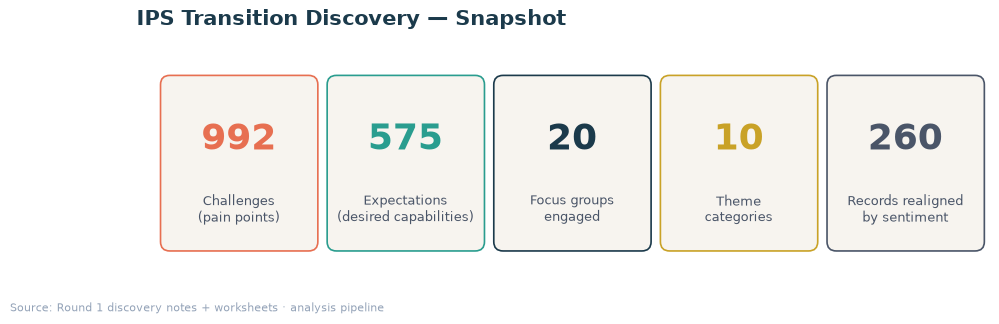

In [31]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.2)
ax.axis("off")
ax.set_title("IPS Transition Discovery — Snapshot", loc="left", fontsize=15, pad=8)

moved = int((ch_scored["sentiment"] == "positive").sum()) + int(
    (ex_scored["sentiment"] == "negative").sum()
)
tiles = [
    (len(challenges), "Challenges\n(pain points)", CORAL),
    (len(expectations), "Expectations\n(desired capabilities)", TEAL),
    (challenges["focus_group"].nunique(), "Focus groups\nengaged", NAVY),
    (challenges["Category"].nunique(), "Theme\ncategories", GOLD),
    (moved, "Records realigned\nby sentiment", SLATE),
]

for i, (value, label, color) in enumerate(tiles):
    x = 0.35 + i * 2.15
    ax.add_patch(
        FancyBboxPatch(
            (x, 0.45),
            1.95,
            2.2,
            boxstyle="round,pad=0.04,rounding_size=0.12",
            linewidth=1.2,
            edgecolor=color,
            facecolor=LIGHT,
        )
    )
    ax.text(x + 0.97, 1.85, f"{value:,}", ha="center", va="center", fontsize=26, fontweight="bold", color=color)
    ax.text(x + 0.97, 0.95, label, ha="center", va="center", fontsize=9, color=SLATE)

fig.text(
    0.01,
    0.02,
    "Source: Round 1 discovery notes + worksheets · analysis pipeline",
    fontsize=8,
    color=MUTED,
)
save(fig, "01_executive_snapshot")
plt.show()


## 3. Challenges vs expectations by theme


Saved output/diagrams/02_category_challenge_vs_expectation.png


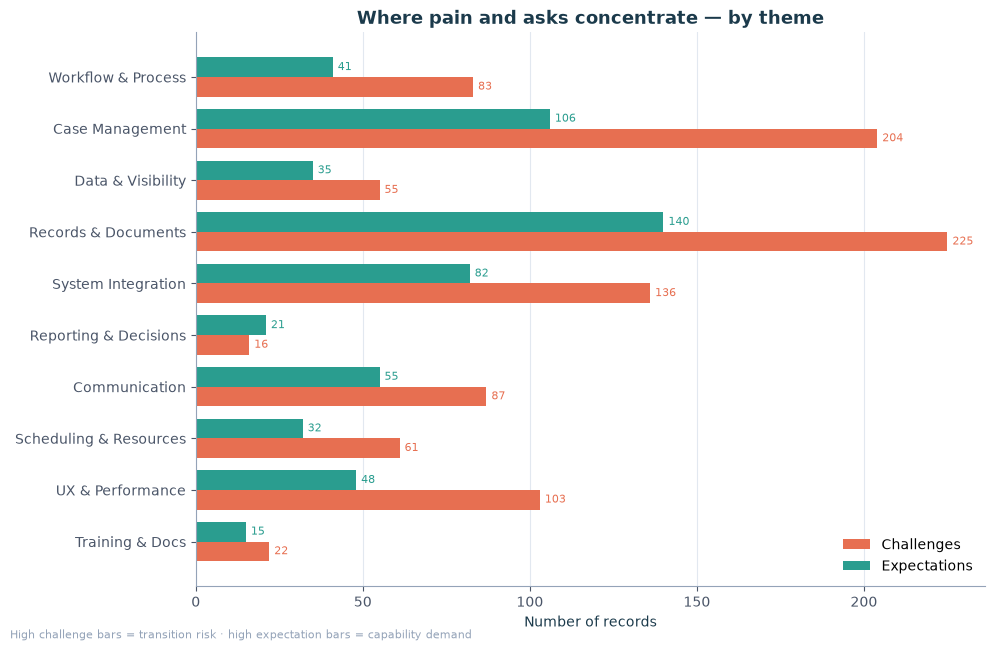

In [32]:
ch_c = challenges["Category"].value_counts()
ex_c = expectations["Category"].value_counts()
cats = [c for c in CATEGORY_ORDER if c in ch_c.index or c in ex_c.index]
y = np.arange(len(cats))
ch_vals = [int(ch_c.get(c, 0)) for c in cats]
ex_vals = [int(ex_c.get(c, 0)) for c in cats]
labels = [SHORT_CAT.get(c, c) for c in cats]

fig, ax = plt.subplots(figsize=(10, 6.5))
h = 0.38
ax.barh(y + h / 2, ch_vals, height=h, color=CORAL, label="Challenges", zorder=2)
ax.barh(y - h / 2, ex_vals, height=h, color=TEAL, label="Expectations", zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Number of records")
ax.set_title("Where pain and asks concentrate — by theme")
ax.legend(frameon=False, loc="lower right")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#E2E8F0", linewidth=0.8)

for yi, cv, ev in zip(y, ch_vals, ex_vals):
    if cv:
        ax.text(cv + 1.5, yi + h / 2, str(cv), va="center", fontsize=8, color=CORAL)
    if ev:
        ax.text(ev + 1.5, yi - h / 2, str(ev), va="center", fontsize=8, color=TEAL)

fig.text(
    0.01,
    0.01,
    "High challenge bars = transition risk · high expectation bars = capability demand",
    fontsize=8,
    color=MUTED,
)
fig.tight_layout()
save(fig, "02_category_challenge_vs_expectation")
plt.show()


## 4. Theme priority matrix (pain vs demand)


Saved output/diagrams/03_priority_matrix.png


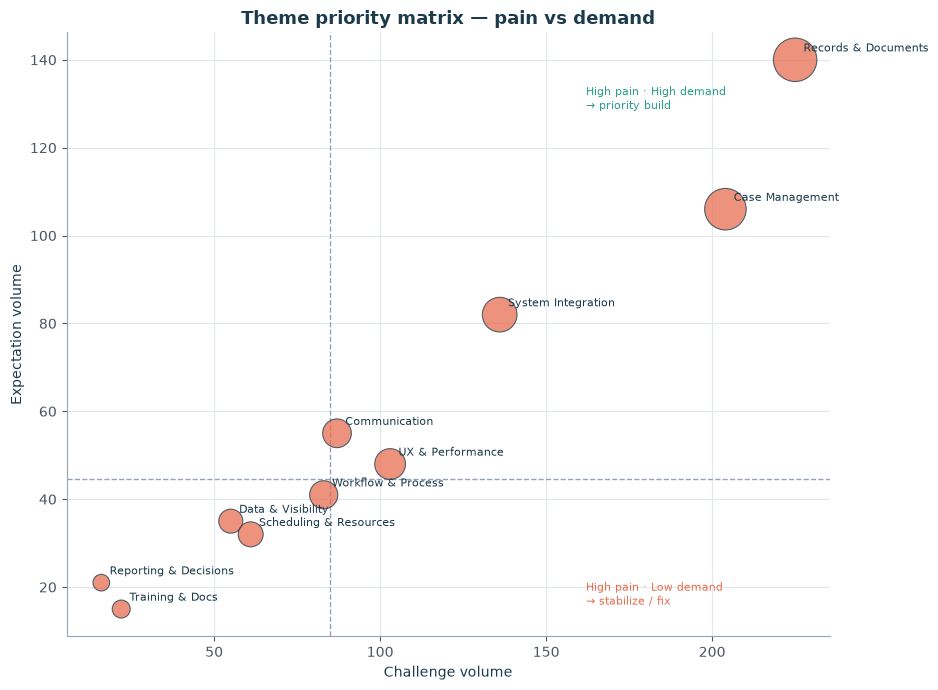

In [33]:
rows = []
for cat in CATEGORY_ORDER:
    c = int((challenges["Category"] == cat).sum())
    e = int((expectations["Category"] == cat).sum())
    if c or e:
        rows.append({"category": SHORT_CAT[cat], "challenges": c, "expectations": e})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.scatter(
    df["challenges"],
    df["expectations"],
    s=df["challenges"] * 4 + 80,
    c=CORAL,
    alpha=0.75,
    edgecolors=NAVY,
    linewidths=0.8,
    zorder=3,
)
for _, r in df.iterrows():
    ax.annotate(
        r["category"],
        (r["challenges"], r["expectations"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
        color=NAVY,
    )

ax.axvline(df["challenges"].median(), color=MUTED, ls="--", lw=1)
ax.axhline(df["expectations"].median(), color=MUTED, ls="--", lw=1)
ax.text(
    df["challenges"].max() * 0.72,
    df["expectations"].max() * 0.92,
    "High pain · High demand\n→ priority build",
    fontsize=8,
    color=TEAL,
)
ax.text(
    df["challenges"].max() * 0.72,
    df["expectations"].min() + 1,
    "High pain · Low demand\n→ stabilize / fix",
    fontsize=8,
    color=CORAL,
)
ax.set_xlabel("Challenge volume")
ax.set_ylabel("Expectation volume")
ax.set_title("Theme priority matrix — pain vs demand")
ax.set_axisbelow(True)
ax.grid(True, color="#E2E8F0", linewidth=0.8)
fig.tight_layout()
save(fig, "03_priority_matrix")
plt.show()


## 5. Top focus groups


Saved output/diagrams/04_top_focus_groups.png


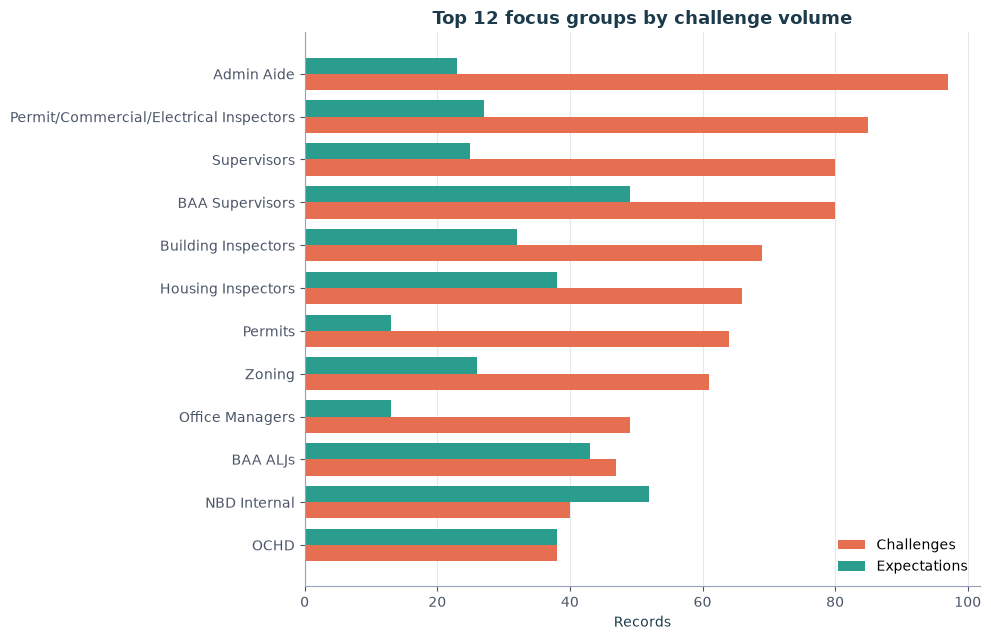

In [34]:
top_n = 12
top = challenges.groupby("focus_group").size().sort_values(ascending=False).head(top_n)
exp = expectations.groupby("focus_group").size()
groups = top.index.tolist()
ch_vals = top.values
ex_vals = [int(exp.get(g, 0)) for g in groups]

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(groups))
h = 0.38
ax.barh(y + h / 2, ch_vals, height=h, color=CORAL, label="Challenges")
ax.barh(y - h / 2, ex_vals, height=h, color=TEAL, label="Expectations")
ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.invert_yaxis()
ax.set_xlabel("Records")
ax.set_title(f"Top {top_n} focus groups by challenge volume")
ax.legend(frameon=False, loc="lower right")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#E2E8F0", linewidth=0.8)
fig.tight_layout()
save(fig, "04_top_focus_groups")
plt.show()


## 6. Sentiment mix (pre-realign)


Saved output/diagrams/05_sentiment_mix.png


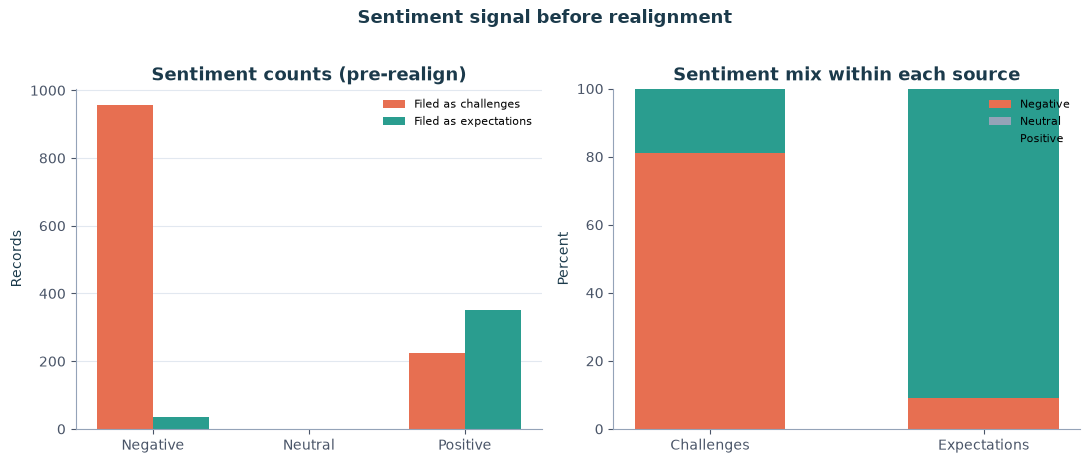

In [35]:
order = ["negative", "neutral", "positive"]
colors = {"negative": CORAL, "neutral": MUTED, "positive": TEAL}

def counts(frame):
    if not isinstance(frame, pd.DataFrame):
        frame = pd.read_csv(frame)
    vc = frame["sentiment"].value_counts()
    return [int(vc.get(s, 0)) for s in order]

ch = counts(ch_scored)
ex = counts(ex_scored)
x = np.arange(len(order))
w = 0.36

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(x - w / 2, ch, width=w, color=CORAL, label="Filed as challenges")
axes[0].bar(x + w / 2, ex, width=w, color=TEAL, label="Filed as expectations")
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.title() for s in order])
axes[0].set_ylabel("Records")
axes[0].set_title("Sentiment counts (pre-realign)")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, color="#E2E8F0", lw=0.8)

def pct(vals):
    total = sum(vals) or 1
    return [100 * v / total for v in vals]

ch_p, ex_p = pct(ch), pct(ex)
bottom = np.zeros(2)
for i, sent in enumerate(order):
    vals = [ch_p[i], ex_p[i]]
    axes[1].bar(["Challenges", "Expectations"], vals, bottom=bottom, color=colors[sent], label=sent.title(), width=0.55)
    bottom = bottom + vals
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percent")
axes[1].set_title("Sentiment mix within each source")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle("Sentiment signal before realignment", fontsize=13, fontweight="bold", color=NAVY, y=1.02)
fig.tight_layout()
save(fig, "05_sentiment_mix")
plt.show()


## 7. Challenge share by theme


Saved output/diagrams/06_challenge_share_donut.png


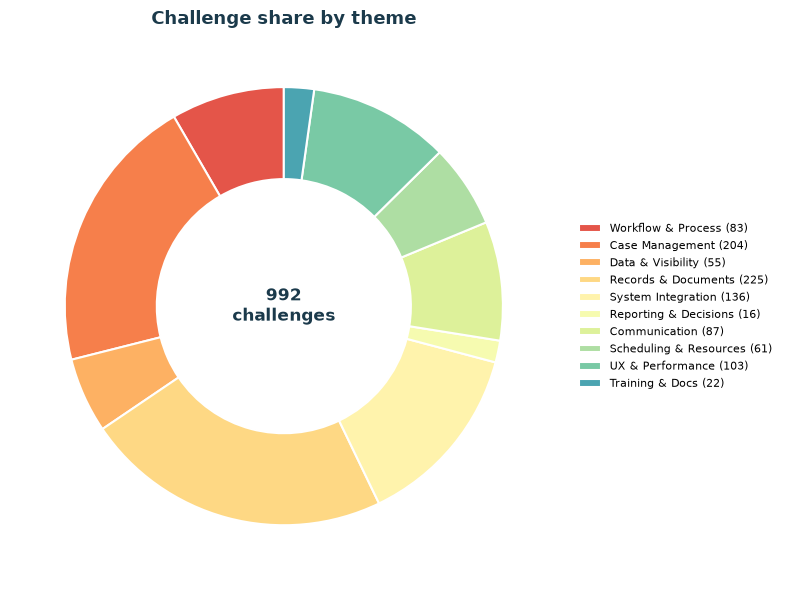

In [36]:
counts = (
    challenges["Category"]
    .value_counts()
    .reindex([c for c in CATEGORY_ORDER if c in challenges["Category"].unique()])
    .dropna()
)
labels = [SHORT_CAT.get(c, c) for c in counts.index]
values = counts.values
cmap = plt.cm.Spectral(np.linspace(0.15, 0.85, len(values)))

fig, ax = plt.subplots(figsize=(9, 6))
wedges, *_ = ax.pie(
    values,
    startangle=90,
    colors=cmap,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.5),
)
ax.text(
    0,
    0,
    f"{int(values.sum()):,}\nchallenges",
    ha="center",
    va="center",
    fontsize=12,
    color=NAVY,
    fontweight="bold",
)
ax.legend(
    wedges,
    [f"{lab} ({v})" for lab, v in zip(labels, values)],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=8,
)
ax.set_title("Challenge share by theme")
fig.tight_layout()
save(fig, "06_challenge_share_donut")
plt.show()


## 8. Theme × focus group heatmap


In [38]:
#group the focus groups by the starting capital letter in the group name
focus_group_order = challenges["focus_group"].str[0].value_counts().sort_values(ascending=False).index

#group the focus groups by the starting capital letter in the group name
focus_group_order = challenges["focus_group"].str[0].value_counts().sort_values(ascending=False).index



Saved output/diagrams/07_heatmap_theme_focus_group.png


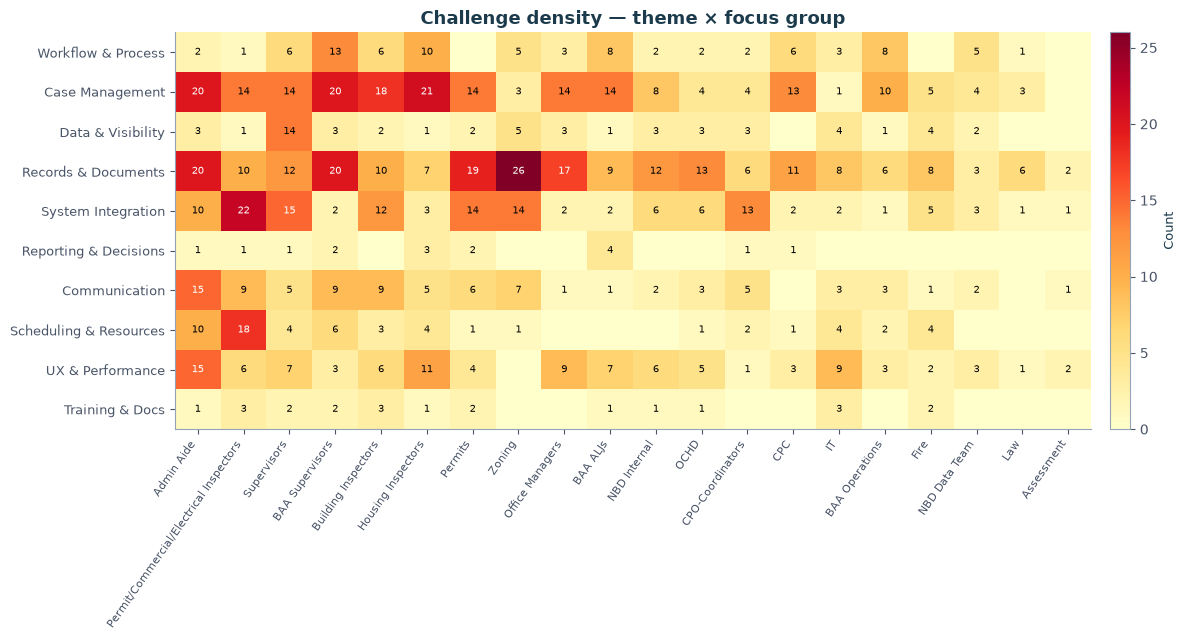

In [39]:
heat = pd.crosstab(challenges["focus_group"], challenges["Category"])
heat = heat.reindex(columns=[c for c in CATEGORY_ORDER if c in heat.columns])
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]
heat = heat.T
heat.index = [SHORT_CAT.get(i, i) for i in heat.index]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(heat.columns, rotation=55, ha="right", fontsize=8)
ax.set_yticklabels(heat.index, fontsize=9)
ax.set_title("Challenge density — theme × focus group")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = int(heat.values[i, j])
        if v:
            ax.text(
                j,
                i,
                str(v),
                ha="center",
                va="center",
                fontsize=7,
                color="black" if v < heat.values.max() * 0.55 else "white",
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Count", fontsize=9)
fig.tight_layout()
save(fig, "07_heatmap_theme_focus_group")
plt.show()


In [ ]:
heat = pd.crosstab(challenges["department"], challenges["Category"])
heat = heat.reindex(columns=[c for c in CATEGORY_ORDER if c in heat.columns])
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]
heat = heat.T
heat.index = [SHORT_CAT.get(i, i) for i in heat.index]

fig, ax = plt.subplots(figsize=(12, 6.5))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(heat.columns, rotation=55, ha="right", fontsize=8)
ax.set_yticklabels(heat.index, fontsize=9)
ax.set_title("Challenge density — theme × department")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = int(heat.values[i, j])
        if v:
            ax.text(
                j,
                i,
                str(v),
                ha="center",
                va="center",
                fontsize=7,
                color="black" if v < heat.values.max() * 0.55 else "white",
            )

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Count", fontsize=9)
fig.tight_layout()
save(fig, "07_heatmap_theme_focus_group")
plt.show()


KeyError: 'department'

## 9. Theme mix in top focus groups


Saved output/diagrams/08_focus_group_theme_mix.png


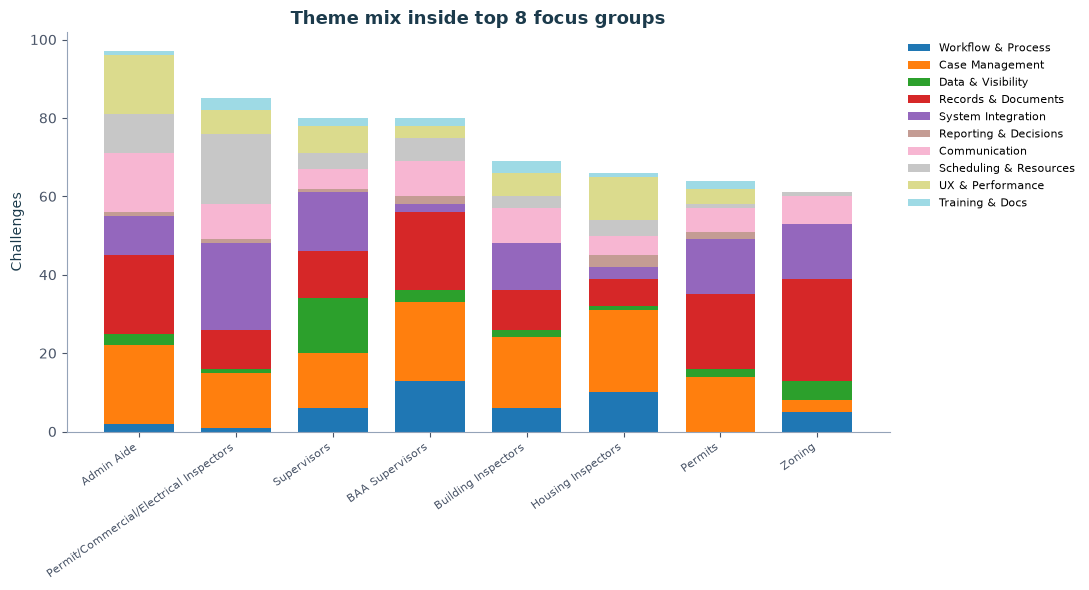

In [40]:
top_groups = 8
top = challenges.groupby("focus_group").size().sort_values(ascending=False).head(top_groups).index
sub = challenges.loc[challenges["focus_group"].isin(top)]
ct = pd.crosstab(sub["focus_group"], sub["Category"])
ct = ct.reindex(index=top)
ct = ct.reindex(columns=[c for c in CATEGORY_ORDER if c in ct.columns], fill_value=0)
ct.columns = [SHORT_CAT.get(c, c) for c in ct.columns]

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.tab20(np.linspace(0, 1, ct.shape[1]))
bottom = np.zeros(len(ct))
x = np.arange(len(ct))
for i, col in enumerate(ct.columns):
    vals = ct[col].values.astype(float)
    ax.bar(x, vals, bottom=bottom, color=colors[i], label=col, width=0.72)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(ct.index, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Challenges")
ax.set_title(f"Theme mix inside top {top_groups} focus groups")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8)
fig.tight_layout()
save(fig, "08_focus_group_theme_mix")
plt.show()
